In [1]:
# Import some basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import geopandas as gpd
import seaborn as sns
import os

In [2]:
sns.set_theme(context="paper", style='whitegrid')

# Figure 1: Map of study area showing training and testing basin locations.

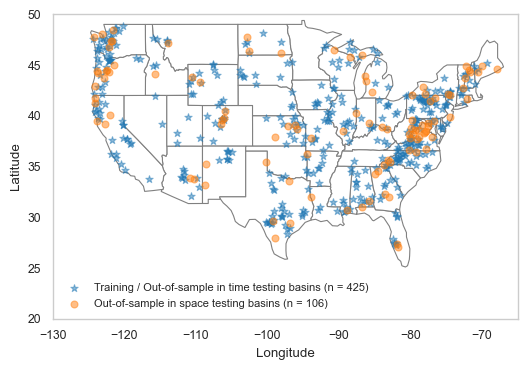

In [230]:
all_camels_basins = pd.read_csv('camels531.csv')
test_camels_basins = pd.read_csv('camels_test_basins.csv')
# remove test basins from all basins to get training basins
train_camels_basins = all_camels_basins[~all_camels_basins['name'].isin(test_camels_basins['name'])]

# show map of US showing training and testing basins using lat and lon columns
shapefile_path = 'Z:/LSTM-Attention4PUB/data/us_shapefile/ne_110m_admin_1_states_provinces_lakes.shp'
us = gpd.read_file(shapefile_path)
us = us[us['admin'] == 'United States of America']
fig, ax = plt.subplots(figsize=(6, 6))
us.plot(ax=ax, color='white', edgecolor='grey')
ax.scatter(train_camels_basins['lon'], train_camels_basins['lat'], color='tab:blue', label=f'Training / Out-of-sample in time testing basins (n = {len(train_camels_basins)})', alpha=0.5, marker='*', s=30)
ax.scatter(test_camels_basins['lon'], test_camels_basins['lat'], color='tab:orange', label=f'Out-of-sample in space testing basins (n = {len(test_camels_basins)})', alpha=0.5, marker='o', s=25)

# ax.set_title('Map of CAMELS Basins: Training (Blue) and Testing (Red)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# limit x and y axis to US extent
ax.set_xlim([-130, -65])
ax.set_ylim([20, 50])
ax.legend(loc = 'lower left', fontsize=8, frameon=False)
plt.grid(False)
plt.savefig('figures/for_paper/1_camels_basins_map.jpg', dpi=600)
plt.savefig('figures/for_paper/1_camels_basins_map.svg')
plt.show()


# Figure 2: NSE plots of 4 model architectures (MLP vs LSTM and single vs ensemble HBV)

In [3]:
def nse(observed, simulated):
    """Calculate Nash-Sutcliffe Efficiency (NSE)"""
    observed_mean = np.mean(observed)
    numerator = np.sum((observed - simulated) ** 2)
    denominator = np.sum((observed - observed_mean) ** 2)
    return 1 - (numerator / denominator)

def get_median_nse(model, unit, exp, oos_type='time'):
    """
    Compute median NSE values for given model/unit/experiment.
    oos_type: 'time' or 'space'
    """
    model_name = f'best_{model}_{unit}hbv'
    out_path = f'output/{exp}'

    all_basin_list = pd.read_csv('camels531.csv')
    ungauged_basins = pd.read_csv(f'{out_path}/{model_name}/test_basins.csv')

    if oos_type == 'time':
        basins = all_basin_list[~all_basin_list['name'].isin(ungauged_basins['name'])]["name"].values
    elif oos_type == 'space':
        basins = ungauged_basins["name"].values
    else:
        raise ValueError("oos_type must be 'time' or 'space'")

    # add leading zero if needed
    gauge_id = [str(gid).zfill(8) for gid in basins]

    median_nse_values = []
    for file in gauge_id:
        try:
            df = pd.read_csv(f'{out_path}/{model_name}/pred_input_{file}.csv')
            df['date'] = pd.to_datetime(df['date'])
            df = df.dropna(subset=['qobs', 'qsim_1'])
            median_nse = nse(df['qobs'].values, df['qsim_1'].values)
            median_nse_values.append(median_nse)
        except:
            continue
    median_nse_values = np.array(median_nse_values)
    median_nse_values = median_nse_values[~np.isnan(median_nse_values)]
    return median_nse_values


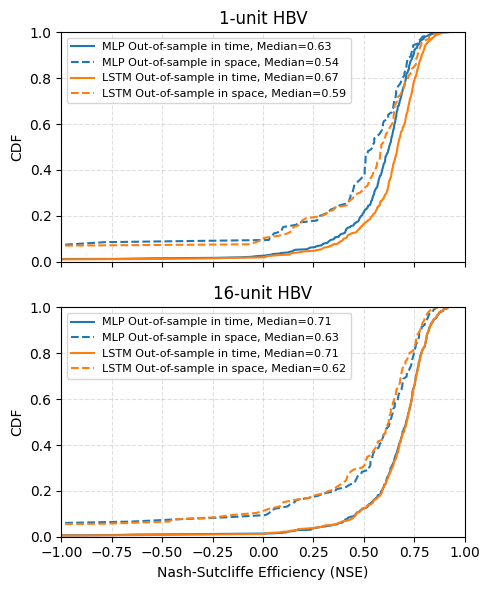

In [6]:
# --- Settings ---
experiments = ''
models = ['mlp', 'lstm']
units = ['1', '16']  # first panel = 1-unit, second panel = 16-unit
colors = {'mlp':'tab:blue', 'lstm':'tab:orange'}  # model color
linestyles = {'time':'-', 'space':'--'}   # OOS type

# Create figure with two panels (shared x-axis)
fig, axes = plt.subplots(2, 1, figsize=(5, 6), sharex=True)

for i, unit in enumerate(units):
    ax = axes[i]
    for model in models:
        # Time OOS
        time_nse = get_median_nse(model, unit, experiments, oos_type='time')
        sorted_time = np.sort(time_nse)
        cdf_time = np.arange(1, len(sorted_time)+1) / len(sorted_time)
        ax.plot(sorted_time, cdf_time,
                color=colors[model],
                linestyle=linestyles['time'],
                lw=1.5,
                label=f'{model.upper()} Out-of-sample in time, Median={np.median(time_nse):.2f}')

        # Space OOS
        space_nse = get_median_nse(model, unit, experiments, oos_type='space')
        sorted_space = np.sort(space_nse)
        cdf_space = np.arange(1, len(sorted_space)+1) / len(sorted_space)
        ax.plot(sorted_space, cdf_space,
                color=colors[model],
                linestyle=linestyles['space'],
                lw=1.5,
                label=f'{model.upper()} Out-of-sample in space, Median={np.median(space_nse):.2f}')

    # ax.axhline(0.5, color='brown', linestyle='--', lw=1)
    ax.set_ylabel('CDF', fontsize=10)          # ✅ CDF on BOTH panels
    ax.set_title(f'{unit}-unit HBV', fontsize=12)
    ax.set_xlim([-1, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)

# X-label only on bottom panel (shared x-axis best practice)
axes[-1].set_xlabel('Nash-Sutcliffe Efficiency (NSE)', fontsize=10)

plt.tight_layout()
plt.savefig('figures/for_paper/2_oos_nse_cdf.jpg', dpi=600)
plt.savefig('figures/for_paper/2_oos_nse_cdf.svg')
plt.show()


# Figure 3: Make KGE, RMSE, Bias, High Flows bias (top10%), Medium Flows bias (30-90%), Low Flows bias (bottom 30%) boxplots

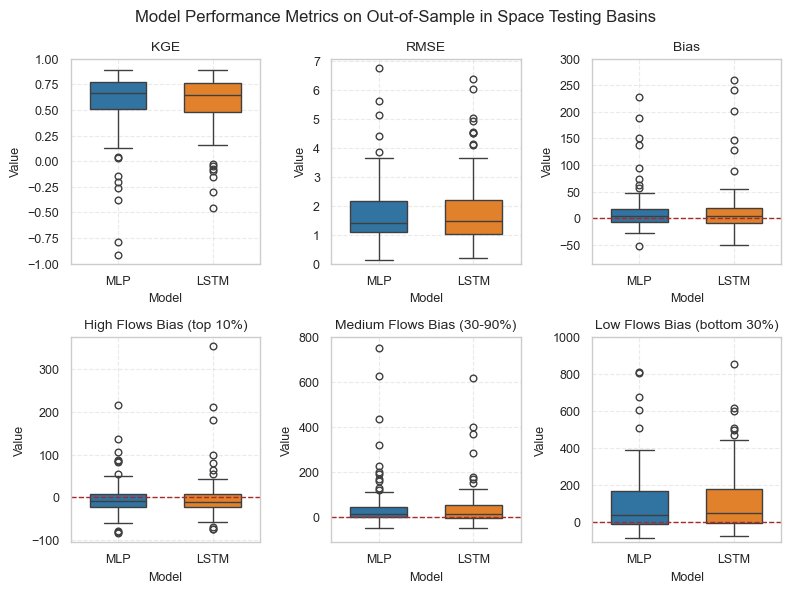

In [233]:
# Metric functions
# ------------------------
def kge(obs, sim):
    r = np.corrcoef(obs, sim)[0,1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    return 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)

def rmse(obs, sim):
    return np.sqrt(np.mean((obs - sim)**2))

def pbias(obs, sim):
    return 100 * np.sum(sim - obs) / np.sum(obs)

def hfb(obs, sim):
    threshold = np.percentile(obs, 90)
    idx = np.where(obs > threshold)[0]
    return 100 * np.sum(sim[idx] - obs[idx]) / np.sum(obs[idx])

def lfb(obs, sim):
    threshold = np.percentile(obs, 30)
    idx = np.where(obs < threshold)[0]
    if np.sum(obs[idx]) == 0:
        return np.nan
    return 100 * np.sum(sim[idx] - obs[idx]) / np.sum(obs[idx])

def mfb(obs, sim):
    lower = np.percentile(obs, 30)
    upper = np.percentile(obs, 90)
    idx = np.where((obs >= lower) & (obs <= upper))[0]
    return 100 * np.sum(sim[idx] - obs[idx]) / np.sum(obs[idx])

# Settings
# ------------------------
metrics = ['KGE', 'RMSE', 'Bias', 'High Flows Bias (top 10%)', 
           'Medium Flows Bias (30-90%)', 'Low Flows Bias (bottom 30%)']
models = ['mlp', 'lstm']
metric_limits = {
    'KGE': (-1, 1),
    'RMSE': (0, None),
    'Bias': (None, 300),
    'High Flows Bias (top 10%)': (None, None),
    'Medium Flows Bias (30-90%)': (-110, 800),
    'Low Flows Bias (bottom 30%)': (-110, 1000)
}

# Read CAMELS basins
all_camels = pd.read_csv('camels531.csv')
test_basins = pd.read_csv('camels_test_basins.csv')

# Compute metrics for each test basin
# ------------------------
records = []

for gauge_id in test_basins['name']:
    gauge_id_str = str(gauge_id).zfill(8)
    for model in models:
        out_file = f'output/best_{model}_16hbv/pred_input_{gauge_id_str}.csv'
        if not os.path.exists(out_file):
            continue
        df = pd.read_csv(out_file).dropna(subset=['qobs', 'qsim_1'])
        obs = df['qobs'].values
        sim = df['qsim_1'].values

        records.append({'Model': model.upper(), 'Metric': 'KGE', 'Value': kge(obs, sim)})
        records.append({'Model': model.upper(), 'Metric': 'RMSE', 'Value': rmse(obs, sim)})
        records.append({'Model': model.upper(), 'Metric': 'Bias', 'Value': pbias(obs, sim)})
        records.append({'Model': model.upper(), 'Metric': 'High Flows Bias (top 10%)', 'Value': hfb(obs, sim)})
        records.append({'Model': model.upper(), 'Metric': 'Medium Flows Bias (30-90%)', 'Value': mfb(obs, sim)})
        lfb_val = lfb(obs, sim)
        if not np.isnan(lfb_val):
            records.append({'Model': model.upper(), 'Metric': 'Low Flows Bias (bottom 30%)', 'Value': lfb_val})

all_metrics = pd.DataFrame.from_records(records)

# Plot boxplots
# ------------------------
# sns.set(style="whitegrid", font_scale=1.0)  # smaller base font scale
fig, axes = plt.subplots(2, 3, figsize=(8, 6))
axes = axes.flatten()

palette = {'MLP':'tab:blue','LSTM':'tab:orange'}

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=all_metrics[all_metrics['Metric'] == metric],
        x='Model', y='Value', hue='Model',  # future-proof
        ax=ax,
        width=0.6,
        palette=palette,
        dodge=False
    )
    
    # Titles and labels
    ax.set_title(metric, fontsize=10)
    ax.set_xlabel('Model', fontsize=9)
    ax.set_ylabel('Value', fontsize=9)
    
    # Ticks
    ax.tick_params(axis='both', labelsize=9)
    
    # Grid
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # Y-limits
    ymin, ymax = metric_limits[metric]
    if ymin is not None or ymax is not None:
        ax.set_ylim(bottom=ymin if ymin is not None else ax.get_ylim()[0],
                    top=ymax if ymax is not None else ax.get_ylim()[1])
    if 'Bias' in metric:
        ax.axhline(0, color='brown', linestyle='--', lw=1)
    
    # Remove legend if exists
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
plt.suptitle('Model Performance Metrics on Out-of-Sample in Space Testing Basins', fontsize=12)
plt.tight_layout()
plt.savefig('figures/for_paper/3_oos_metrics_boxplots.jpg', dpi=600)
plt.savefig('figures/for_paper/3_oos_metrics_boxplots.svg')
plt.show()


# Figure 4: Few vs many input features

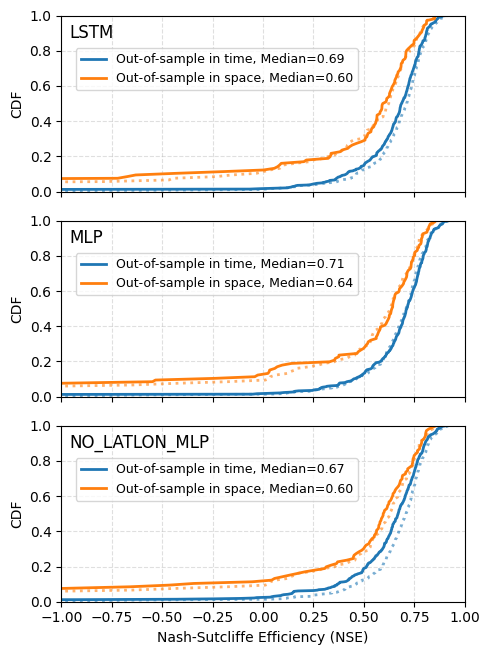

In [7]:
# --- Settings ---
experiments = ['', 'exp_thinned']
models = ['lstm', 'mlp', 'no_latlon_mlp']
unit = '16'

# Color by OOS type
oos_colors = {'time':'tab:blue', 'space':'tab:orange'}
# Line style by experiment: dotted for all data, solid for thinned
exp_linestyles = {'':'dotted', 'exp_thinned':'solid'}
# Dim color for reference (all data)
exp_alpha = {'':'0.6', 'exp_thinned':'1.0'}

# Create figure with 3 panels
fig, axes = plt.subplots(3, 1, figsize=(5, 7), sharex=True)

for i, model in enumerate(models):
    ax = axes[i]
    # Panel title inside plot (top left)
    ax.text(0.02, 0.95, model.upper(), transform=ax.transAxes, fontsize=12, verticalalignment='top')

    for exp in experiments:
        # Time OOS
        time_nse = get_median_nse(model, unit, exp, oos_type='time')
        sorted_time = np.sort(time_nse)
        cdf_time = np.arange(1, len(sorted_time)+1)/len(sorted_time)
        ax.plot(sorted_time, cdf_time,
                color=oos_colors['time'],
                linestyle=exp_linestyles[exp],
                alpha=float(exp_alpha[exp]),
                lw=2,
                label=f'Out-of-sample in time, Median={np.median(time_nse):.2f}' if exp=='exp_thinned' else None)

        # Space OOS
        space_nse = get_median_nse(model, unit, exp, oos_type='space')
        sorted_space = np.sort(space_nse)
        cdf_space = np.arange(1, len(sorted_space)+1)/len(sorted_space)
        ax.plot(sorted_space, cdf_space,
                color=oos_colors['space'],
                linestyle=exp_linestyles[exp],
                alpha=float(exp_alpha[exp]),
                lw=2,
                label=f'Out-of-sample in space, Median={np.median(space_nse):.2f}' if exp=='exp_thinned' else None)

    # ax.axhline(0.5, color='brown', linestyle='--', lw=1)
    ax.set_ylabel('CDF', fontsize=10)
    ax.set_xlim([-1, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # Legend below panel title
    ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(0.02, 0.85))

axes[-1].set_xlabel('Nash-Sutcliffe Efficiency (NSE)', fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('figures/for_paper/4_oos_nse_cdf_thinned_vs_all.jpg', dpi=600)
plt.savefig('figures/for_paper/4_oos_nse_cdf_thinned_vs_all.svg')
plt.show()


# Figure 5: Map showing the average coefficient of variation of parameters across basins

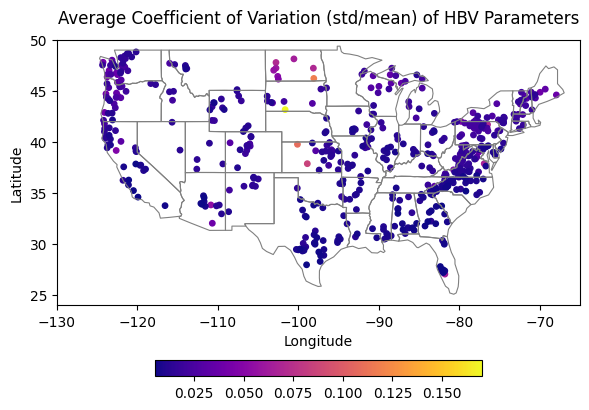

In [2]:

# --- Settings
param_names = [ "fc", "beta", "pwp", "l", "ks", "ki", "kb", "kperc",
                "coeff_pet", "ddf", "scf", "ts", "tm", "tti", "whc",
                "crf", "d_shape", "d_scale", "b_shape", "b_scale"]

basin_list = pd.read_csv("camels531.csv")
basin_list['name'] = basin_list['name'].apply(lambda x: str(x).zfill(8))

shapefile_path = 'Z:/LSTM-Attention4PUB/data/us_shapefile/ne_110m_admin_1_states_provinces_lakes.shp'
us = gpd.read_file(shapefile_path)
us = us[us['admin'] == 'United States of America']

output_dir = "figures/hbv_parameters"
os.makedirs(output_dir, exist_ok=True)

## map showing the average coefficient of variation across all parameters per basin
# create a filtered list of parameter names excluding 'tm' and 'ts' to avoid high CV due to near-zero means
filtered_param_names = [p for p in param_names if p not in ['tm', 'ts']]

param_var_all = {}
for basin in basin_list['name']:
    param_file = f"output/best_lstm_1hbv_parameters/input_{basin}_parameters.csv"
    df_params = pd.read_csv(param_file)
    df_params['date'] = pd.to_datetime(df_params['date'])
    # remove tm and ts as their mean is close to zero causing high cv relative to others
    df_params = df_params.drop(columns=['tm', 'ts'], errors='ignore')
    # only keep for training years: 1990-2005
    df_params = df_params[(df_params['date'] >= '1990-01-01') & (df_params['date'] <= '2005-12-31')]
    cv_list = []
    for param in filtered_param_names:
        mean_val = np.mean(df_params[param].values)
        std_val = np.std(df_params[param].values)
        cv = std_val / mean_val if mean_val != 0 else 0
        cv_list.append(cv)
    param_var_all[basin] = np.mean(cv_list) if len(cv_list) > 0 else 0
param_var_all_df = pd.DataFrame.from_dict(param_var_all, orient='index', columns=['avg_cv']).reset_index().rename(columns={'index': 'basin'})
# sort and save to csv
param_var_all_df = param_var_all_df.sort_values(by='avg_cv', ascending=False)
param_var_all_df.to_csv(f"{output_dir}/avg_cv_all_parameters_per_basin.csv", index=False)
param_var_all_df = param_var_all_df.merge(basin_list[['name', 'lat', 'lon']], left_on='basin', right_on='name', how='left')
param_var_all_gdf = gpd.GeoDataFrame(
    param_var_all_df,
    geometry=gpd.points_from_xy(param_var_all_df.lon, param_var_all_df.lat),
    crs="EPSG:4326"
)
# Plot map
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
us.boundary.plot(ax=ax, color='grey', linewidth=0.8)
g = param_var_all_gdf.plot(column='avg_cv', ax=ax, cmap='plasma', markersize=15, legend=False)
sm = plt.cm.ScalarMappable(cmap='plasma', 
                           norm=plt.Normalize(vmin=param_var_all_gdf['avg_cv'].min(),
                                              vmax=param_var_all_gdf['avg_cv'].max()))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.10)
ax.set_title('Average Coefficient of Variation (std/mean) of HBV Parameters', fontsize=12, pad=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim([-130, -65])
ax.set_ylim([24, 50])
# ax.set_aspect('equal')
plt.grid(False)
# plt.legend()
plt.tight_layout()
plt.savefig(f"figures/for_paper/avg_cv_all_parameters_map.jpg", dpi=600)
plt.savefig(f"figures/for_paper/avg_cv_all_parameters_map.svg")
plt.show()

# Figure 6: Map showing the average coefficient of variation of LSTM generated HBV parameters across basins

Use 3 basins with high (highest variability basin with decent nse), medium, and low variability
1532000 (high variabiilty) 10336660 (medium variability), 2465493 (low variability)

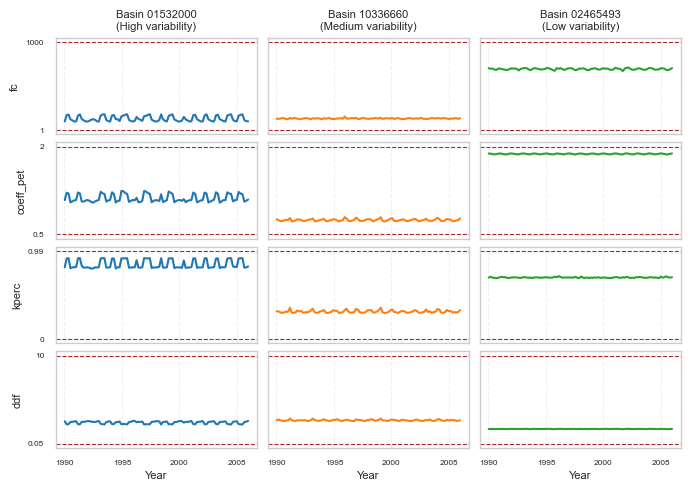

In [20]:
# Parameter bounds
# ------------------------
param_bounds = {
    "fc": [1.0, 1000.0],
    "beta": [0.5, 5.0],
    "pwp": [0.01, 0.99],
    "l": [1.0, 999.0],
    "ks": [0.01, 0.99],
    "ki": [0.01, 0.99],
    "kb": [0.001, 0.99],
    "kperc": [0.0001, 0.99],
    "coeff_pet": [0.5, 2.0],
    "ddf": [0.05, 10.0],
    "scf": [0.5, 2.0],
    "ts": [-4.0, 4.0],
    "tm": [-4.0, 4.0],
    "tti": [0.1, 4.0],
    "whc": [0.05, 0.2],
    "crf": [0.1, 1.0],
    "d_shape": [1.0, 4.0],
    "d_scale": [0.5, 4.0],
    "b_shape": [1.0, 6.0],
    "b_scale": [1.0, 7.0],
}

# ------------------------
# Settings
# ------------------------
basins = [
    ('01532000', 'High variability', 'tab:blue'),
    ('10336660', 'Medium variability', 'tab:orange'),
    ('02465493', 'Low variability', 'tab:green')
]

param_names = ['fc', 'coeff_pet', 'kperc', 'ddf']
start_date, end_date = '1990-01-01', '2005-12-31'

# Figure layout (params x basins)
# ------------------------
fig, axes = plt.subplots(
    nrows=len(param_names),
    ncols=len(basins),
    figsize=(7, 5),
    sharex=True,
    sharey='row'
)

# Plot
# ------------------------
for j, (basin, variability, color) in enumerate(basins):
    param_file = f"output/best_lstm_1hbv_parameters/input_{basin}_parameters.csv"
    df = pd.read_csv(param_file, parse_dates=['date'])

    df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

    for i, param in enumerate(param_names):
        ax = axes[i, j]

        # Time series (same color per basin)
        ax.plot(
            df['date'],
            df[param],
            color=color,
            lw=1.5
        )

        # Parameter bounds
        low, high = param_bounds[param]
        ax.axhline(low, color='brown', ls='--', lw=0.8, alpha=1)
        ax.axhline(high, color='brown', ls='--', lw=0.8, alpha=1)

        # Fix y-ticks to min & max and format to ≤2 decimals
        ax.set_yticks([low, high])
        ax.yaxis.set_major_formatter(
            lambda x, _: f'{x:.2f}'.rstrip('0').rstrip('.')
        )

        # Basin titles (top row)
        if i == 0:
            ax.set_title(
                f'Basin {basin}\n({variability})',
                fontsize=8
            )

        # Parameter labels (left column)
        if j == 0:
            ax.set_ylabel(param, fontsize=8)

        ax.grid(True, linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=6)

# X-axis formatting
# ------------------------
for ax in axes[-1, :]:
    ax.set_xlabel('Year', fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Layout
# ------------------------
plt.tight_layout(w_pad=0.6, h_pad=0.6)
plt.savefig(f'figures/for_paper/5_hbv_parameter_time_series_basin.jpg', dpi=600)
plt.savefig(f'figures/for_paper/5_hbv_parameter_time_series_basin.svg')
plt.show()


# Figure 7: Equifinality of LSTM generated HBV parameters

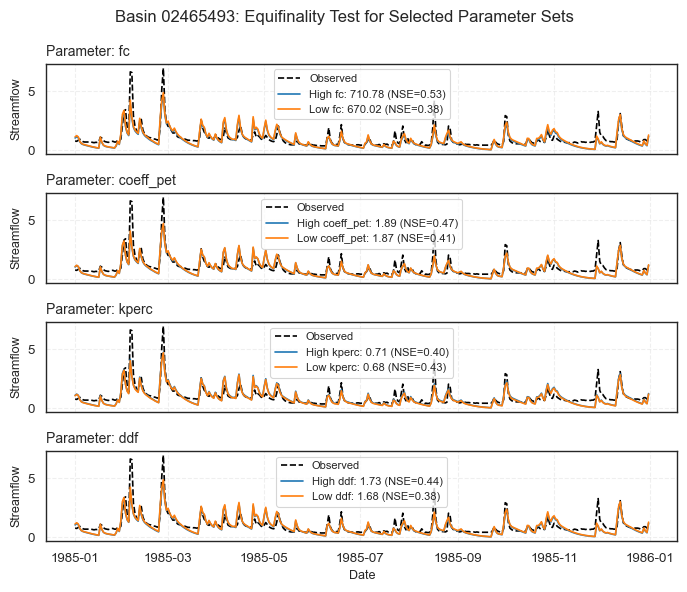

In [45]:
# User settings
# ------------------------
basin_id = "02465493" # show one basin at a time (highest variability in main, and other two throw in supplement)
# 01532000 (high variabiilty) 10336660 (medium variability), 02465493 (low variability)
use_params = ['fc', 'coeff_pet', 'kperc', 'ddf']

# ------------------------
# NSE function
# ------------------------
def nse(obs, sim):
    return 1 - np.sum((obs - sim)**2) / np.sum((obs - np.mean(obs))**2)

# ------------------------
# Create figure
# ------------------------
fig, axes = plt.subplots(len(use_params), 1, figsize=(7, 6), sharex=True)
plt.subplots_adjust(hspace=0.35)

for i, param in enumerate(use_params):
    ax = axes[i]
    
    # Read equifinality results for this parameter
    results_df = pd.read_csv(f'output/best_lstm_1hbv_equifinality/equifinality_test_{basin_id}_{param}.csv')
    results_df['date'] = pd.to_datetime(results_df['date'])
    
    # High/low parameter values
    param_file = f"output/best_lstm_1hbv_parameters/input_{basin_id}_parameters.csv"
    param_sets = pd.read_csv(param_file)
    high_val = np.round(param_sets[param].max(), 2)
    low_val  = np.round(param_sets[param].min(), 2)
    
    # Test period
    test_mask = (results_df['date'] >= '1980-01-01') & (results_df['date'] <= '1989-12-31')
    results_df_test = results_df[test_mask]
    
    # NSE
    nse_high = nse(results_df_test['qobs'], results_df_test[f'qsim_high_{param}'])
    nse_low  = nse(results_df_test['qobs'], results_df_test[f'qsim_low_{param}'])
    
    # Plot observed
    plot_period_mask = (results_df['date'] >= '1985-01-01') & (results_df['date'] <= '1985-12-31')
    results_df = results_df[plot_period_mask]
    ax.plot(results_df['date'], results_df['qobs'], color='black', lw=1.2, label='Observed', linestyle='--')
    
    # Plot high and low simulations
    ax.plot(results_df['date'], results_df[f'qsim_high_{param}'], color='tab:blue', lw=1.2,
            label=f'High {param}: {high_val} (NSE={nse_high:.2f})')
    ax.plot(results_df['date'], results_df[f'qsim_low_{param}'], color='tab:orange', lw=1.2,
            label=f'Low {param}: {low_val} (NSE={nse_low:.2f})')
    
    ax.set_ylabel('Streamflow', fontsize=9)
    ax.set_title(f'Parameter: {param}', fontsize=10, loc='left')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(fontsize=8, loc='best')

# X-axis formatting
axes[-1].set_xlabel('Date', fontsize=9)
plt.xticks(rotation=0)

plt.suptitle(f'Basin {basin_id}: Equifinality Test for Selected Parameter Sets', fontsize=12)
plt.tight_layout()
# plt.savefig(f'figures/for_paper/6_equifinality_test_basin_{basin_id}.jpg', dpi=600)
# plt.savefig(f'figures/for_paper/6_equifinality_test_basin_{basin_id}.svg')
plt.show()


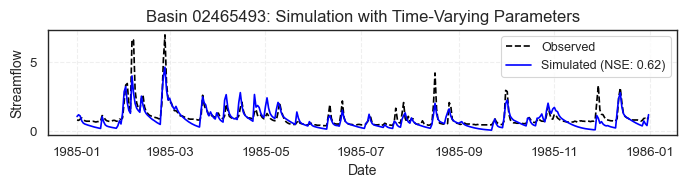

In [46]:
# plot with time varying parameters for the same basin
flow_dynamic_param = pd.read_csv(f'output/best_lstm_1hbv_dynamic_sim/pred_input_{basin_id}.csv', parse_dates=['date'])
# calculate test period nse
test_mask = (flow_dynamic_param['date'] >= '1980-01-01') & (flow_dynamic_param['date'] <= '1989-12-31')
flow_dynamic_param_test = flow_dynamic_param[test_mask]
nse_dynamic = nse(flow_dynamic_param_test['qobs'], flow_dynamic_param_test['qsim_1'])

# Plot observed
plot_period_mask = (flow_dynamic_param['date'] >= '1985-01-01') & (flow_dynamic_param['date'] <= '1985-12-31')

# Plot observed vs simulated with dynamic parameters
plt.figure(figsize=(7, 2))
plt.plot(flow_dynamic_param.loc[plot_period_mask, 'date'],
         flow_dynamic_param.loc[plot_period_mask, 'qobs'],
         color='black', lw=1.2, label='Observed', linestyle='--')
plt.plot(flow_dynamic_param.loc[plot_period_mask, 'date'],
         flow_dynamic_param.loc[plot_period_mask, 'qsim_1'],
         color='blue', lw=1.2, label=f'Simulated (NSE: {nse_dynamic:.2f})')
plt.xlabel('Date', fontsize=10)
plt.ylabel('Streamflow', fontsize=10)
plt.title(f'Basin {basin_id}: Simulation with Time-Varying Parameters', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.savefig(f'figures/for_paper/6.1_dynamic_parameter_simulation_basin_{basin_id}.jpg', dpi=600)
plt.savefig(f'figures/for_paper/6.1_dynamic_parameter_simulation_basin_{basin_id}.svg')
plt.show()

# Figure: LSTM+1HBV simulation with dynamic parameters

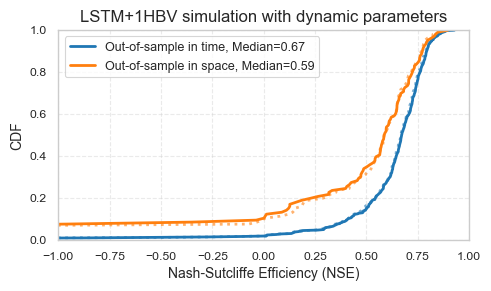

In [23]:
# --- Settings ---
experiments = ['', 'exp_dynamic_sim']
model = 'lstm'
unit = '1'

# Color by OOS type
oos_colors = {'time': 'tab:blue', 'space': 'tab:orange'}

# Line style by experiment
exp_linestyles = {'': 'dotted', 'exp_dynamic_sim': 'solid'}
exp_alpha = {'': 0.6, 'exp_dynamic_sim': 1.0}

# Create single figure
fig, ax = plt.subplots(figsize=(5, 3))

for exp in experiments:

    # --- Time OOS ---
    time_nse = get_median_nse(model, unit, exp, oos_type='time')
    sorted_time = np.sort(time_nse)
    cdf_time = np.arange(1, len(sorted_time) + 1) / len(sorted_time)

    ax.plot(
        sorted_time,
        cdf_time,
        color=oos_colors['time'],
        linestyle=exp_linestyles[exp],
        alpha=exp_alpha[exp],
        lw=2,
        label=f'Out-of-sample in time, Median={np.median(time_nse):.2f}'
        if exp == 'exp_dynamic_sim' else None
    )

    # --- Space OOS ---
    space_nse = get_median_nse(model, unit, exp, oos_type='space')
    sorted_space = np.sort(space_nse)
    cdf_space = np.arange(1, len(sorted_space) + 1) / len(sorted_space)

    ax.plot(
        sorted_space,
        cdf_space,
        color=oos_colors['space'],
        linestyle=exp_linestyles[exp],
        alpha=exp_alpha[exp],
        lw=2,
        label=f'Out-of-sample in space, Median={np.median(space_nse):.2f}'
        if exp == 'exp_dynamic_sim' else None
    )

# Formatting
ax.set_xlabel('Nash-Sutcliffe Efficiency (NSE)', fontsize=10)
ax.set_ylabel('CDF', fontsize=10)
ax.set_xlim([-1, 1])
ax.set_ylim([0, 1])
ax.grid(True, linestyle='--', alpha=0.4)

ax.legend(fontsize=9, loc='upper left')
ax.set_title('LSTM+1HBV simulation with dynamic parameters', fontsize=12)

plt.tight_layout()

plt.savefig('figures/for_paper/6.2_oos_nse_cdf_dynamic_vs_static.jpg', dpi=600)
plt.savefig('figures/for_paper/6.2_oos_nse_cdf_dynamic_vs_static.svg')
plt.show()


# HBV Parameter correlation pair-plot

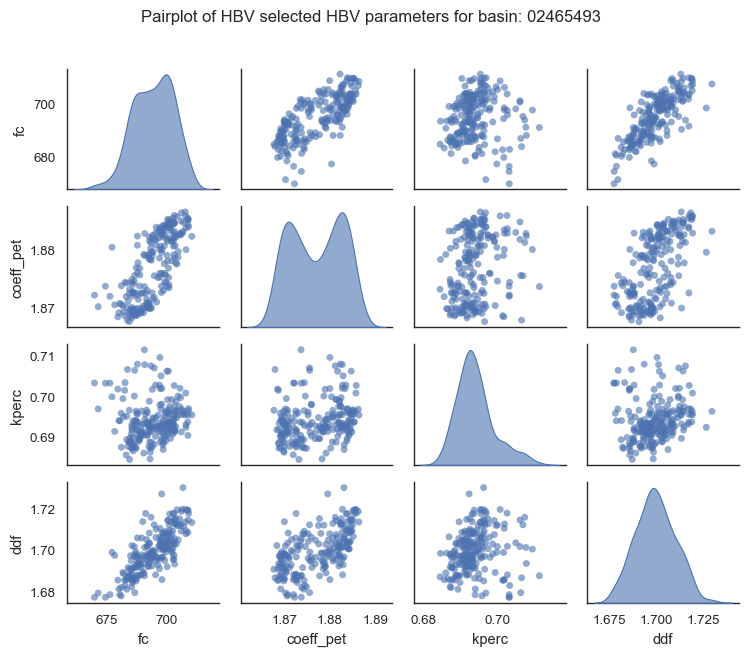

In [42]:
# Show scatter pairplot of selected parameters for one basin
basin_id = "02465493"
# 01532000 (high variability), 10336660 (medium variability), 02465493 (low variability)

# Read parameter sets
param_sets = pd.read_csv(
    f"output/best_lstm_1hbv_parameters/input_{basin_id}_parameters.csv"
)

# Drop date column if present
param_sets = param_sets.drop(columns=["date"], errors="ignore")

# Select parameters of interest
use_pars = ["fc", "coeff_pet", "kperc", "ddf"]
param_sets = param_sets[use_pars]

# Set clean style
sns.set_style("white")
sns.set_context("paper", font_scale=1.1)

# Pairplot
g = sns.pairplot(
    param_sets,
    diag_kind="kde",
    plot_kws=dict(s=25, alpha=0.6, edgecolor="none"),
    diag_kws=dict(fill=True, alpha=0.6),
    height=1.6,
    aspect=1.2
)

# Title (pairplot requires fig-level title)
g.fig.suptitle(
    f"Pairplot of HBV selected HBV parameters for basin: {basin_id}",
    fontsize=12,
    y=1.02
)

# Tight layout with room for title
g.fig.tight_layout()

# Save
g.fig.savefig(
    f"figures/for_paper/6.3_parameter_pairplot_{basin_id}.jpg",
    dpi=600,
    bbox_inches="tight"
)
g.fig.savefig(
    f"figures/for_paper/6.3_parameter_pairplot_{basin_id}.svg",
    bbox_inches="tight"
)

plt.show()


# Figure 8: XAI feature importance results

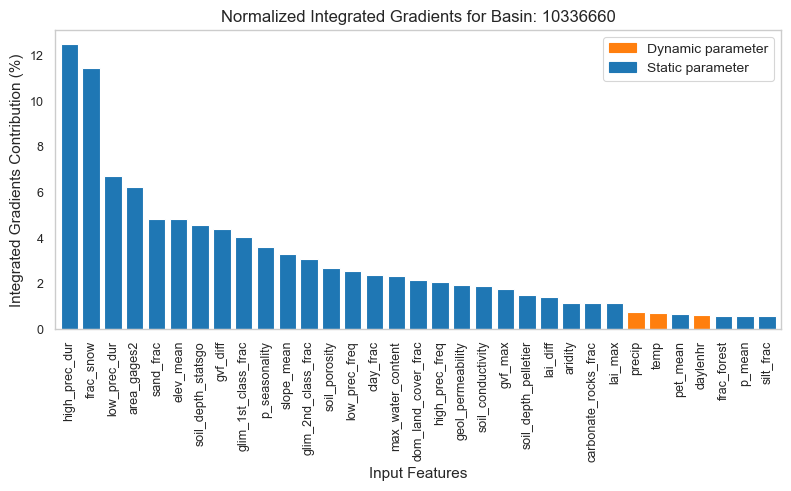

In [238]:
# Settings
# ------------------------
basin = '10336660'  # high: 01532000, medium: 10336660, low: 02465493
param_names = [
    "fc", "beta", "pwp", "l", "ks", "ki", "kb", "kperc",
    "coeff_pet", "ddf", "scf", "ts", "tm", "tti", "whc",
    "crf", "d_shape", "d_scale", "b_shape", "b_scale"
]
highlight_features = ['daylenhr', 'temp', 'precip']

# Merge IG dataframes for all parameters
# ------------------------
df_merged = pd.concat([
    pd.read_csv(f'output/integrated_gradients/lstm_1hbv/ig_lstm_hbv_{basin}_par_{par}.csv')
    .drop(columns=['date', 'lag'], errors='ignore')
    for par in param_names
], ignore_index=True)

# Compute normalized mean absolute IG
# ------------------------
mean_abs = df_merged.abs().mean()
mean_abs_normalized = 100 * mean_abs / mean_abs.sum()
mean_abs_normalized = mean_abs_normalized.sort_values(ascending=False)

# Color mapping: red for highlighted features, blue otherwise
colors = ['tab:orange' if f in highlight_features else 'tab:blue' for f in mean_abs_normalized.index]

# Plot
# ------------------------
plt.figure(figsize=(8, 5))
mean_abs_normalized.plot(kind='bar', color=colors, width=0.8)

# Legend patches
legend_patches = [Patch(color='tab:orange', label='Dynamic parameter'),
                  Patch(color='tab:blue', label='Static parameter')]
plt.legend(handles=legend_patches, fontsize=10)

plt.title(f'Normalized Integrated Gradients for Basin: {basin}', fontsize=12)
plt.ylabel('Integrated Gradients Contribution (%)', fontsize=11)
plt.xlabel('Input Features', fontsize=11)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
# plt.ylim(0, mean_abs_normalized.max() * 1.1)
plt.grid(False)

plt.tight_layout()
plt.savefig(f'figures/for_paper/7_ig_normalized_basin_{basin}.jpg', dpi=600)
plt.savefig(f'figures/for_paper/7_ig_normalized_basin_{basin}.svg')
plt.show()